In [1]:
# ==========================================================
# USED CAR PRICE PREDICTION USING MACHINE LEARNING
# Course: Intelligent AI and Data Engineering
# STEP 1: BUSINESS UNDERSTANDING & DATASET LOADING
# ==========================================================

# ==========================================================
# BUSINESS PROBLEM
# ==========================================================
"""
Business Problem:
-----------------
The automobile market contains thousands of used cars with different
prices depending on their characteristics such as brand, model,
manufacturing year, mileage, engine specifications, transmission type,
fuel type, accident history, and other features.

Accurately estimating the selling price of a used car is difficult
because many factors influence its value.

The objective of this project is to build a Machine Learning Regression
model capable of predicting the selling price of a used car based on
its features.

This prediction system can help:

• Buyers avoid overpaying.
• Sellers determine a fair selling price.
• Car dealerships automate vehicle valuation.
• Online car marketplaces provide instant price estimates.
"""

# ==========================================================
# IMPORT LIBRARIES
# ==========================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("Set2")

# Display Settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 120)

print("="*70)
print("USED CAR PRICE PREDICTION")
print("="*70)

# ==========================================================
# LOAD DATASET
# ==========================================================

df = pd.read_csv("used_cars.csv")

print("\nDataset Loaded Successfully.\n")

# ==========================================================
# BASIC INFORMATION
# ==========================================================

print("="*70)
print("First Five Rows")
print("="*70)

display(df.head())

print("="*70)
print("Last Five Rows")
print("="*70)

display(df.tail())

print("="*70)
print("Dataset Shape")
print("="*70)

print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

print("="*70)
print("Column Names")
print("="*70)

print(df.columns.tolist())

print("="*70)
print("Dataset Information")
print("="*70)

df.info()

print("="*70)
print("Data Types")
print("="*70)

display(df.dtypes)

print("="*70)
print("Statistical Summary (Numerical)")
print("="*70)

display(df.describe().T)

print("="*70)
print("Statistical Summary (Categorical)")
print("="*70)

display(df.describe(include="object"))

# ==========================================================
# TARGET VARIABLE
# ==========================================================

TARGET = "price"

print("="*70)
print("Target Variable")
print("="*70)

print(f"Target Variable : {TARGET}")

# ==========================================================
# FEATURE DESCRIPTION
# ==========================================================

feature_description = pd.DataFrame({
    "Feature":[
        "brand",
        "model",
        "model_year",
        "milage",
        "fuel_type",
        "engine",
        "transmission",
        "ext_col",
        "int_col",
        "accident",
        "clean_title",
        "price"
    ],
    "Description":[
        "Car manufacturer",
        "Car model",
        "Manufacturing year",
        "Total distance driven",
        "Fuel type",
        "Engine specification",
        "Transmission type",
        "Exterior color",
        "Interior color",
        "Accident history",
        "Title status",
        "Selling price (Target)"
    ]
})

print("="*70)
print("Feature Description")
print("="*70)

display(feature_description)

# ==========================================================
# REGRESSION PROBLEM JUSTIFICATION
# ==========================================================

print("="*70)
print("Why is this a Regression Problem?")
print("="*70)

print("""
The target variable is 'price'.

Price is a continuous numerical value.

Regression algorithms are used whenever the target variable
contains continuous values rather than categories.

Therefore, this project is a Supervised Machine Learning
Regression problem.
""")

print("="*70)
print("STEP 1 COMPLETED SUCCESSFULLY")
print("="*70)

USED CAR PRICE PREDICTION

Dataset Loaded Successfully.

First Five Rows


,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"


Last Five Rows


,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
4004,Bentley,Continental GT Speed,2023,714 mi.,Gasoline,6.0L W12 48V PDI DOHC Twin Turbo,8-Speed Automatic with Auto-Shift,C / C,Hotspur,None reported,Yes,"$349,950"
4005,Audi,S4 3.0T Premium Plus,2022,"10,900 mi.",Gasoline,349.0HP 3.0L V6 Cylinder Engine Gasoline Fuel,Transmission w/Dual Shift Mode,Black,Black,None reported,Yes,"$53,900"
4006,Porsche,Taycan,2022,"2,116 mi.",NaN,Electric,Automatic,Black,Black,None reported,NaN,"$90,998"
4007,Ford,F-150 Raptor,2020,"33,000 mi.",Gasoline,450.0HP 3.5L V6 Cylinder Engine Gasoline Fuel,A/T,Blue,Black,None reported,Yes,"$62,999"
4008,BMW,X3 xDrive30i,2020,"43,000 mi.",Gasoline,248.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,A/T,Gray,Brown,At least 1 accident or damage reported,Yes,"$40,000"


Dataset Shape
Rows    : 4009
Columns : 12
Column Names
['brand', 'model', 'model_year', 'milage', 'fuel_type', 'engine', 'transmission', 'ext_col', 'int_col', 'accident', 'clean_title', 'price']
Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   brand         4009 non-null   object
 1   model         4009 non-null   object
 2   model_year    4009 non-null   int64 
 3   milage        4009 non-null   object
 4   fuel_type     3839 non-null   object
 5   engine        4009 non-null   object
 6   transmission  4009 non-null   object
 7   ext_col       4009 non-null   object
 8   int_col       4009 non-null   object
 9   accident      3896 non-null   object
 10  clean_title   3413 non-null   object
 11  price         4009 non-null   object
dtypes: int64(1), object(11)
memory usage: 376.0+ KB
Data Types


...

Statistical Summary (Categorical)


,brand,model,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
count,4009,4009,4009,3839,4009,4009,4009,4009,3896,3413,4009
unique,57,1898,2818,7,1146,62,319,156,2,1,1569
top,Ford,M3 Base,"110,000 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,A/T,Black,Black,None reported,Yes,"$15,000"
freq,386,30,16,3309,52,1037,905,2025,2910,3413,39


Target Variable
Target Variable : price
Feature Description


,Feature,Description
0,brand,Car manufacturer
1,model,Car model
2,model_year,Manufacturing year
3,milage,Total distance driven
4,fuel_type,Fuel type
5,engine,Engine specification
6,transmission,Transmission type
7,ext_col,Exterior color
8,int_col,Interior color
9,accident,Accident history


Why is this a Regression Problem?

The target variable is 'price'.

Price is a continuous numerical value.

Regression algorithms are used whenever the target variable
contains continuous values rather than categories.

Therefore, this project is a Supervised Machine Learning
Regression problem.

STEP 1 COMPLETED SUCCESSFULLY


In [2]:
# ==========================================================
# STEP 2: DATA CLEANING & PREPROCESSING
# ==========================================================
import re

print("=" * 70)
print("STEP 2: DATA CLEANING & PREPROCESSING")
print("=" * 70)

# ==========================================================
# CHECK DUPLICATE ROWS
# ==========================================================

duplicates = df.duplicated().sum()

print("\nDuplicate Rows:", duplicates)

if duplicates > 0:
    df.drop_duplicates(inplace=True)
    print(f"{duplicates} duplicate rows removed successfully.")
else:
    print("No duplicate rows found.")

# ==========================================================
# CHECK MISSING VALUES
# ==========================================================

print("\n" + "=" * 70)
print("MISSING VALUES")
print("=" * 70)

missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": round((df.isnull().sum()/len(df))*100,2)
})

display(missing[missing["Missing Values"]>0].sort_values(by="Missing Values",ascending=False))

# ==========================================================
# HANDLE MISSING VALUES
# ==========================================================

# Numerical Columns
numerical_columns = df.select_dtypes(include=["int64","float64"]).columns.tolist()

# Remove target variable from numerical columns
if "price" in numerical_columns:
    numerical_columns.remove("price")

# Fill numerical missing values with Median
for col in numerical_columns:
    df[col].fillna(df[col].median(), inplace=True)
print("\nNumerical missing values filled using Median.")
print("="*70)
# Categorical Columns
categorical_columns = df.select_dtypes(include="object").columns.tolist()
print(categorical_columns)
print("="*70)

# Fill categorical missing values with Mode
for col in categorical_columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

print("Categorical missing values filled using Mode.")

# ==========================================================
# VERIFY MISSING VALUES
# ==========================================================

print("\nRemaining Missing Values")

display(df.isnull().sum())

# ==========================================================
# REMOVE ID COLUMN (NOT USEFUL FOR PREDICTION)
# ==========================================================

if "id" in df.columns:
    df.drop("id", axis=1, inplace=True)
    print("\n'id' column removed successfully.")
else:
    print("\nNo 'id' column found.")

# ==========================================================
# CHECK DATASET SHAPE
# ==========================================================

print("\nDataset Shape After Cleaning")

print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

# ==========================================================
# CHECK DATA TYPES
# ==========================================================

print("\nDataset Information")

df.info()

# ==========================================================
# UNIQUE VALUES OF CATEGORICAL FEATURES
# ==========================================================

print("\n" + "=" * 70)
print("UNIQUE VALUES IN CATEGORICAL FEATURES")
print("=" * 70)

for col in categorical_columns:
    if col in df.columns:
        print(f"{col:<15} : {df[col].nunique()} unique values")

# ==========================================================
# CHECK FOR NEGATIVE PRICE
# ==========================================================
print("="*80)
print(df["price"].dtype)
print("="*80)

# ==========================================================
# Convert Price Data type to numeric
# ==========================================================
df["price"] = (
    df["price"]
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
)
df["price"] = pd.to_numeric(df["price"], errors="coerce")

print("="*80)
print(df["price"].dtype)
print("="*80)

if (df["price"] <= 0).sum() > 0:
    print("\nRemoving invalid price values...")
    df = df[df["price"] > 0]
else:
    print("\nAll price values are valid.")

# ==========================================================
# Convert milage to numeric
# ==========================================================
df["milage"] = (
    df["milage"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.replace(" mi", "", regex=False)
    .str.strip()
    .astype(float)
)


print(df["milage"].head())


# ==========================================================
# Convert engine to numeric
# ==========================================================
df["engine"] = (
    df["engine"]
    .astype(str)
    .str.extract(r'(\d+\.\d+)')
    .astype(float)
)
print(df["engine"].head())
print("==================================================================================")
# Map accident column
df["accident"] = df["accident"].map({
    "None reported": 0,
    "At least 1 accident or damage reported": 1
})

# Fill missing values (original NaN values) with 0
df["accident"] = df["accident"].fillna(0).astype(int)

print(df["accident"].unique())
print(df["accident"].isnull().sum())
print("==================================================================================")

df.drop(
    "clean_title",
    axis=1,
    inplace=True
)
# ==========================================================
# FINAL DATASET SUMMARY
# ==========================================================

print("\n" + "=" * 70)
print("FINAL DATASET SUMMARY")
print("=" * 70)

display(df.head())
print("\nDataset Shape:", df.shape)
print("\nData Cleaning Completed Successfully.")

print("=" * 70)
print("STEP 2 COMPLETED")
print("=" * 70)



STEP 2: DATA CLEANING & PREPROCESSING

Duplicate Rows: 0
No duplicate rows found.

MISSING VALUES


,Missing Values,Percentage
clean_title,596,14.87
fuel_type,170,4.24
accident,113,2.82



Numerical missing values filled using Median.
['brand', 'model', 'milage', 'fuel_type', 'engine', 'transmission', 'ext_col', 'int_col', 'accident', 'clean_title', 'price']
Categorical missing values filled using Mode.

Remaining Missing Values


brand           0
model           0
model_year      0
milage          0
fuel_type       0
engine          0
transmission    0
ext_col         0
int_col         0
accident        0
clean_title     0
price           0
dtype: int64


No 'id' column found.

Dataset Shape After Cleaning
Rows    : 4009
Columns : 12

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   brand         4009 non-null   object
 1   model         4009 non-null   object
 2   model_year    4009 non-null   int64 
 3   milage        4009 non-null   object
 4   fuel_type     4009 non-null   object
 5   engine        4009 non-null   object
 6   transmission  4009 non-null   object
 7   ext_col       4009 non-null   object
 8   int_col       4009 non-null   object
 9   accident      4009 non-null   object
 10  clean_title   4009 non-null   object
 11  price         4009 non-null   object
dtypes: int64(1), object(11)
memory usage: 376.0+ KB

UNIQUE VALUES IN CATEGORICAL FEATURES
brand           : 57 unique values
model           : 1898 unique values
milage          : 2818 unique values
fu

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,price
0,Ford,Utility Police Interceptor Base,2013,51000.0,E85 Flex Fuel,300.0,6-Speed A/T,Black,Black,1,10300
1,Hyundai,Palisade SEL,2021,34742.0,Gasoline,3.8,8-Speed Automatic,Moonlight Cloud,Gray,1,38005
2,Lexus,RX 350 RX 350,2022,22372.0,Gasoline,3.5,Automatic,Blue,Black,0,54598
3,INFINITI,Q50 Hybrid Sport,2015,88900.0,Hybrid,354.0,7-Speed A/T,Black,Black,0,15500
4,Audi,Q3 45 S line Premium Plus,2021,9835.0,Gasoline,2.0,8-Speed Automatic,Glacier White Metallic,Black,0,34999



Dataset Shape: (4009, 11)

Data Cleaning Completed Successfully.
STEP 2 COMPLETED


STEP 3: EXPLORATORY DATA ANALYSIS (EDA)

Dataset Shape
(4009, 11)

Dataset Columns
['brand', 'model', 'model_year', 'milage', 'fuel_type', 'engine', 'transmission', 'ext_col', 'int_col', 'accident', 'price']

Statistical Summary


,count,mean,std,min,25%,50%,75%,max
model_year,4009.0,2015.515590,6.104816,1974.0,2012.0,2017.0,2020.0,2024.0
milage,4009.0,64717.551010,52296.599459,100.0,23044.0,52775.0,94100.0,405000.0
engine,3906.0,272.800128,168.095932,1.2,180.0,290.0,382.0,1020.0
accident,4009.0,0.245947,0.430701,0.0,0.0,0.0,0.0,1.0
price,4009.0,44553.190322,78710.635554,2000.0,17200.0,31000.0,49990.0,2954083.0


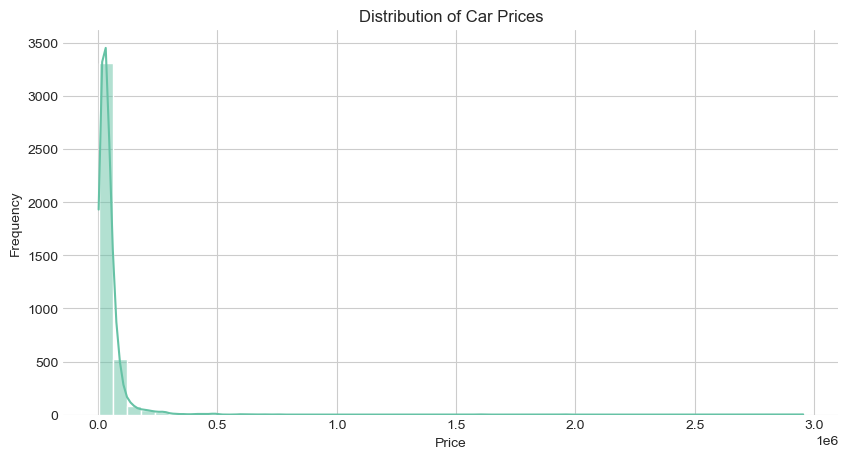

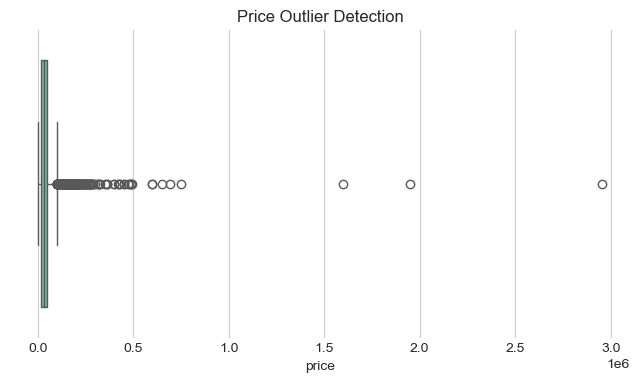

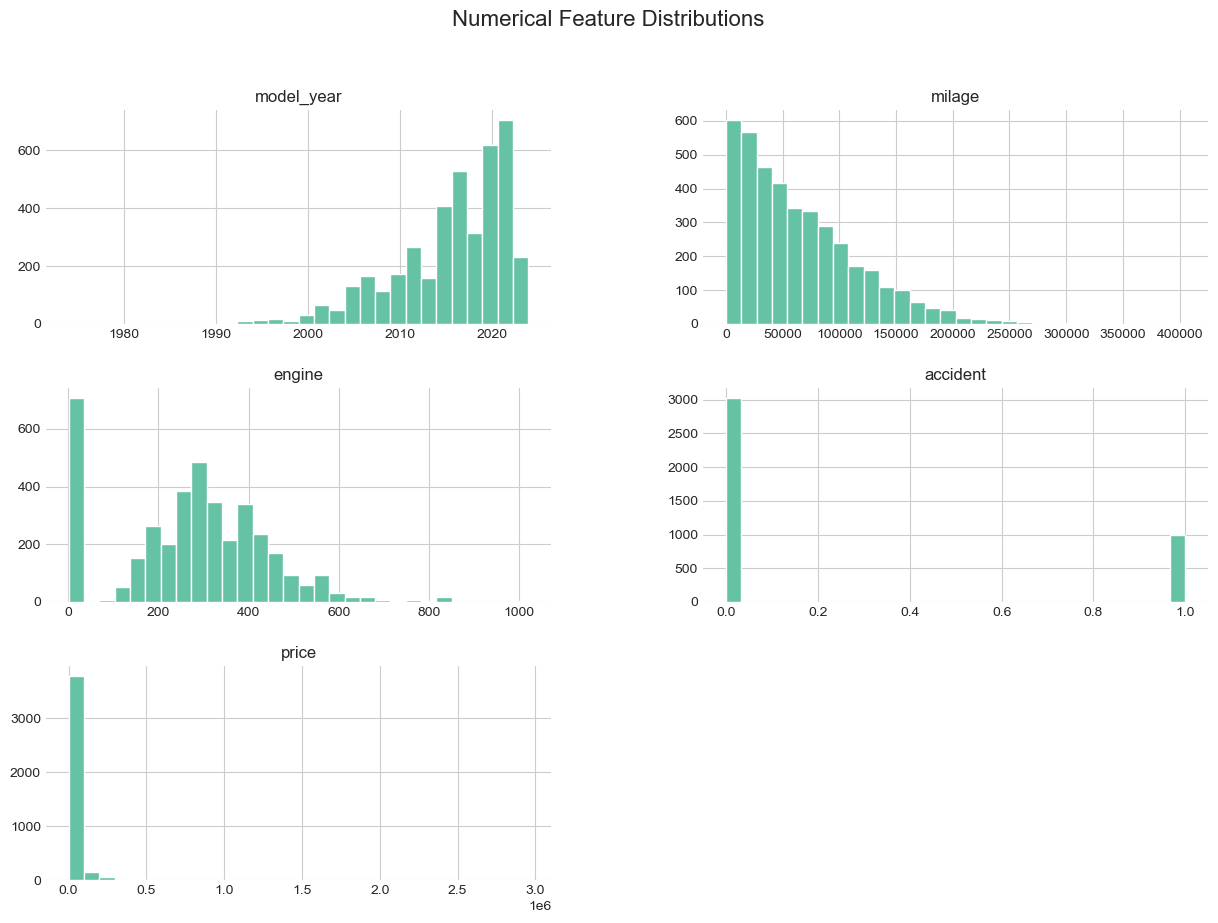

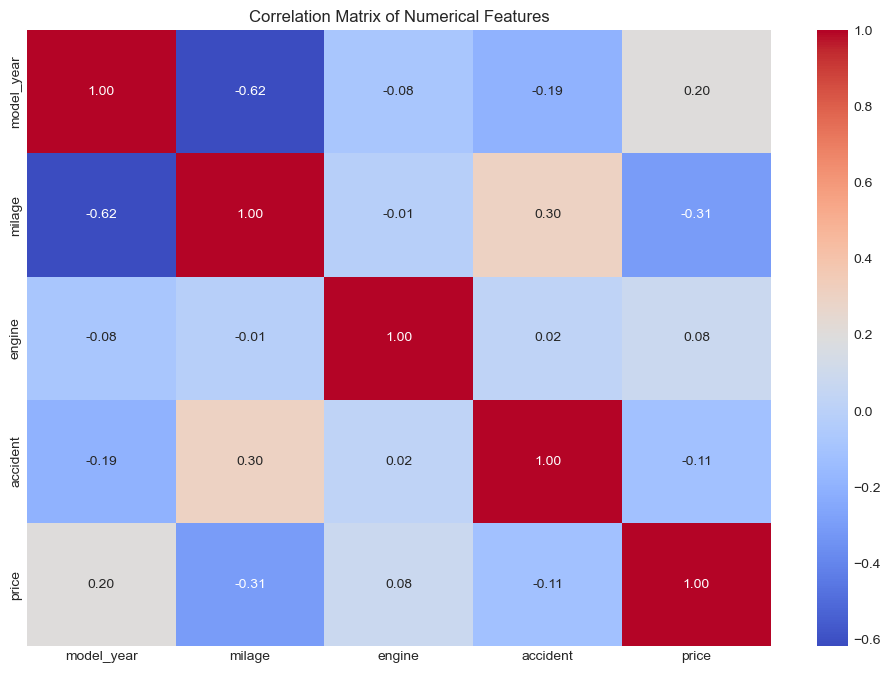

Correlation With Price


price         1.000000
model_year    0.199496
engine        0.079086
accident     -0.114088
milage       -0.305528
Name: price, dtype: float64

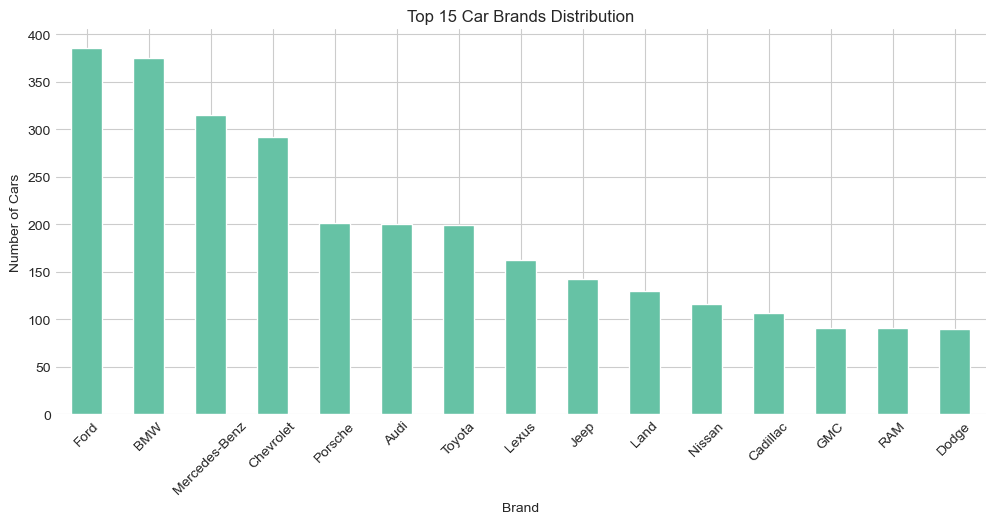

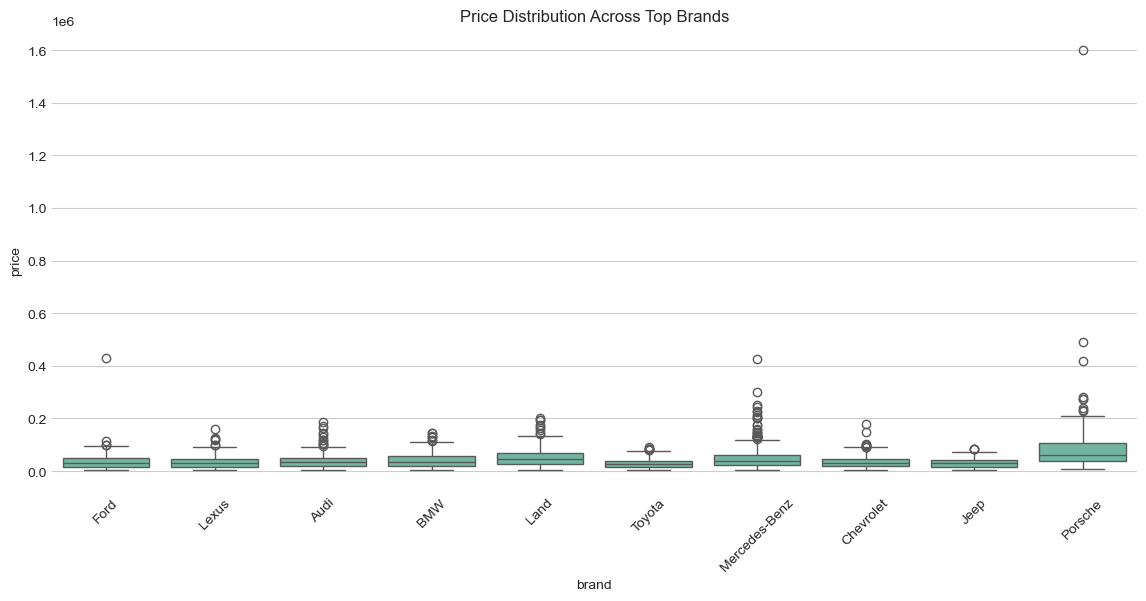

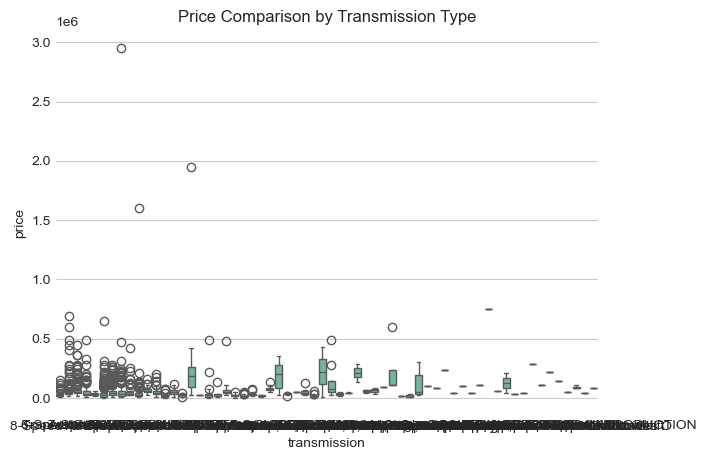

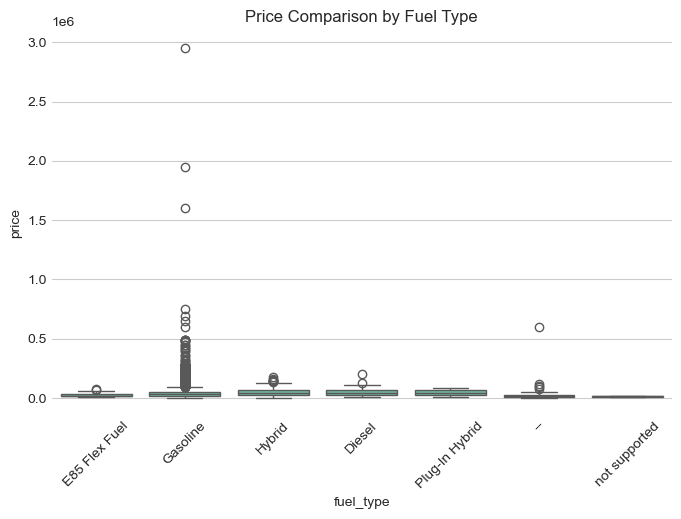

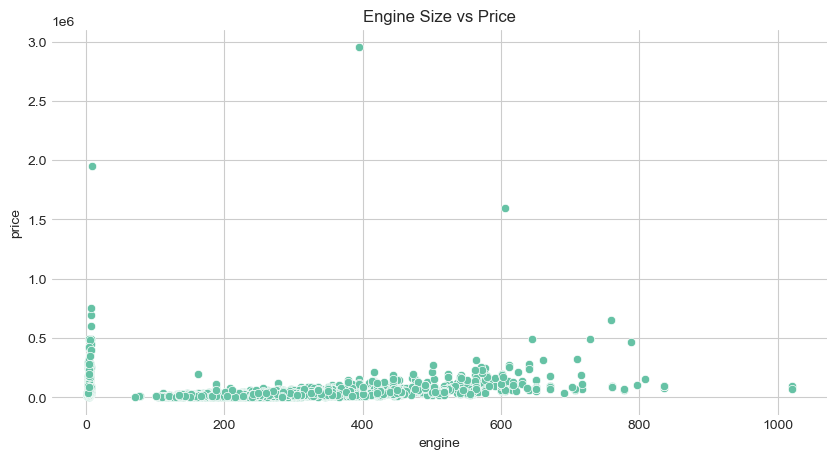

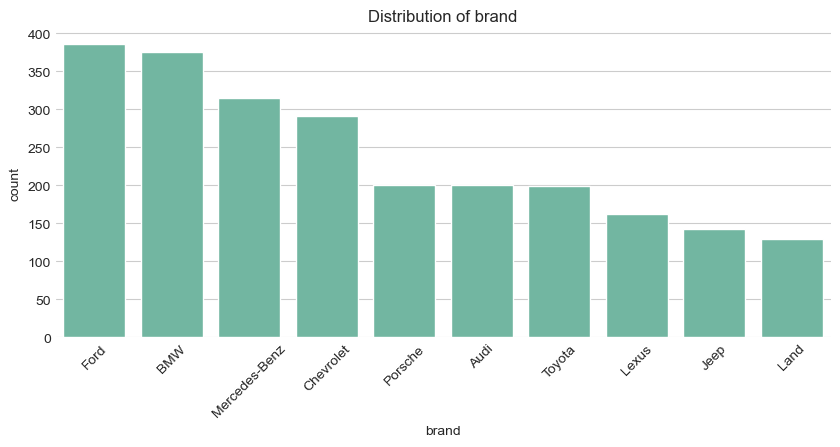

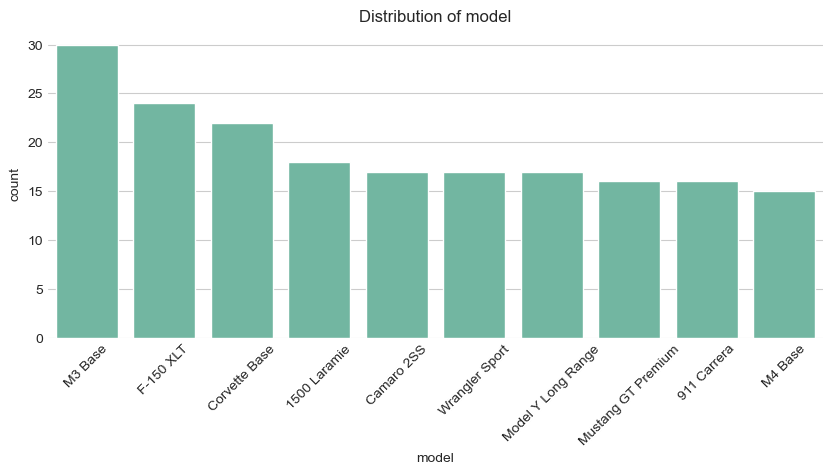

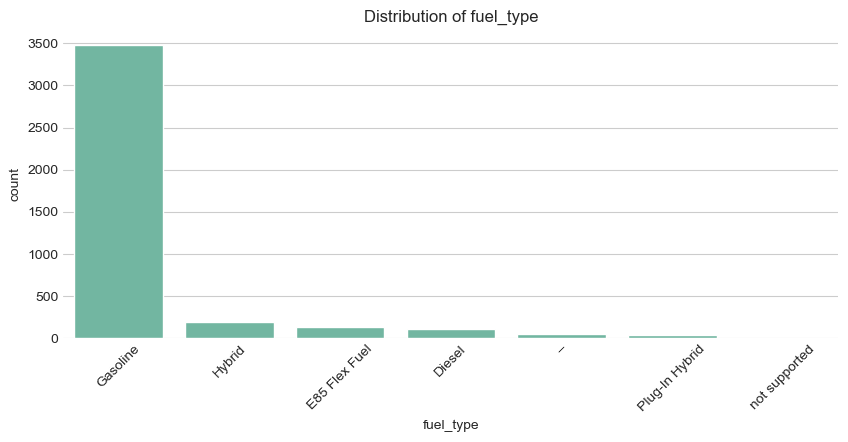

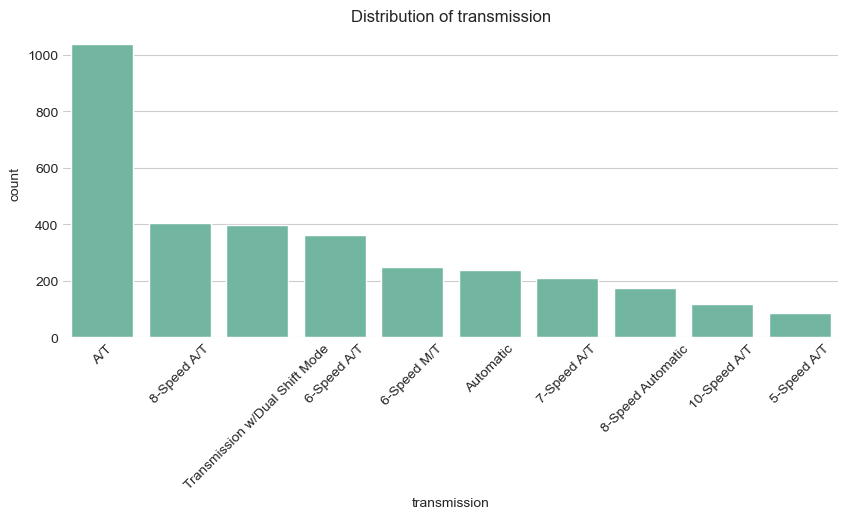

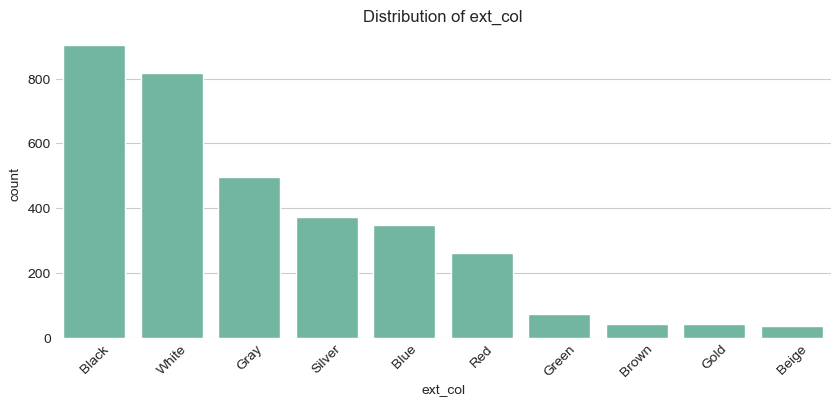

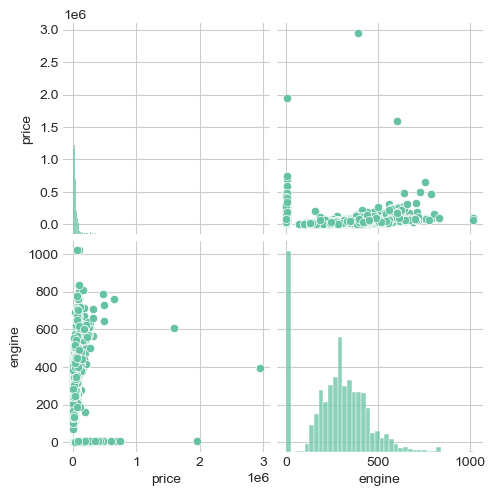

EDA COMPLETED SUCCESSFULLY


In [3]:
# ==========================================================
# STEP 3: EXPLORATORY DATA ANALYSIS (EDA)
# ==========================================================
print("=" * 70)
print("STEP 3: EXPLORATORY DATA ANALYSIS (EDA)")
print("=" * 70)

# Import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")


# ==========================================================
# 1. DATASET OVERVIEW
# ==========================================================
print("\nDataset Shape")
print(df.shape)
print("\nDataset Columns")
print(df.columns.tolist())
print("\nStatistical Summary")
display(df.describe().T)


# ==========================================================
# 2. TARGET VARIABLE DISTRIBUTION
# ==========================================================
plt.figure(figsize=(10,5))
sns.histplot(df["price"],bins=50,kde=True)
plt.title("Distribution of Car Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

# ==========================================================
# 3. PRICE BOX PLOT (OUTLIER DETECTION)
# ==========================================================
plt.figure(figsize=(8,4))
sns.boxplot(x=df["price"])
plt.title("Price Outlier Detection")
plt.show()

# ==========================================================
# 4. NUMERICAL FEATURE DISTRIBUTIONS
# ==========================================================
numerical_features = df.select_dtypes(include=["int64","float64"]).columns
df[numerical_features].hist(figsize=(15,10),bins=30)
plt.suptitle("Numerical Feature Distributions",fontsize=16)
plt.show()

# ==========================================================
# 5. CORRELATION MATRIX
# ==========================================================
plt.figure(figsize=(12,8))
correlation = df[numerical_features].corr()
sns.heatmap(correlation,annot=True,cmap="coolwarm",fmt=".2f")
plt.title("Correlation Matrix of Numerical Features")
plt.show()

# ==========================================================
# 6. FEATURES MOST CORRELATED WITH PRICE
# ==========================================================
price_corr = correlation["price"].sort_values(ascending=False)
print("Correlation With Price")
display(price_corr)

# ==========================================================
# 7. PRICE VS YEAR
# ==========================================================
if "year" in df.columns:
    plt.figure(figsize=(10,5))
    sns.scatterplot(data=df,x="year",y="price")
    plt.title("Car Price vs Manufacturing Year")
    plt.show()

# ==========================================================
# 8. PRICE VS MILEAGE
# ==========================================================
mileage_columns = [
    col for col in df.columns 
    if "mile" in col.lower() or "km" in col.lower()
]
if len(mileage_columns)>0:
    mileage=mileage_columns[0]
    plt.figure(figsize=(10,5))
    sns.scatterplot(data=df,x=mileage,y="price")
    plt.title("Price vs Mileage")
    plt.show()

# ==========================================================
# 9. TOP BRANDS BY COUNT
# ==========================================================
brand_columns = [
    col for col in df.columns 
    if "brand" in col.lower()]
if len(brand_columns)>0:
    brand=brand_columns[0]
    plt.figure(figsize=(12,5))
    df[brand].value_counts().head(15).plot(kind="bar")
    plt.title("Top 15 Car Brands Distribution")
    plt.xlabel("Brand")
    plt.ylabel("Number of Cars")
    plt.xticks(rotation=45)
    plt.show()

# ==========================================================
# 10. PRICE DISTRIBUTION BY BRAND
# ==========================================================
if len(brand_columns)>0:
    plt.figure(figsize=(14,6))
    top_brands = (
        df[brand]
        .value_counts()
        .head(10)
        .index
    )
    sns.boxplot(data=df[df[brand].isin(top_brands)],x=brand,y="price")
    plt.title("Price Distribution Across Top Brands")
    plt.xticks(rotation=45)
    plt.show()

# ==========================================================
# 11. TRANSMISSION ANALYSIS
# ==========================================================
if "transmission" in df.columns:
    plt.figure(figsize=(7,5))
    sns.boxplot(data=df,x="transmission",y="price")
    plt.title("Price Comparison by Transmission Type")
    plt.show()
    
# ==========================================================
# 12. FUEL TYPE ANALYSIS
# ==========================================================
fuel_columns=[
    col for col in df.columns
    if "fuel" in col.lower()]
if len(fuel_columns)>0:
    fuel=fuel_columns[0]
    plt.figure(figsize=(8,5))
    sns.boxplot(data=df,x=fuel,y="price")
    plt.title("Price Comparison by Fuel Type")
    plt.xticks(rotation=45)
    plt.show()

# ==========================================================
# 13. PRICE BY ENGINE SIZE
# ==========================================================
engine_columns=[
    col for col in df.columns
    if "engine" in col.lower()]
if len(engine_columns)>0:
    engine=engine_columns[0]
    plt.figure(figsize=(10,5))
    sns.scatterplot(data=df,x=engine,y="price")
    plt.title("Engine Size vs Price")
    plt.show()

# ==========================================================
# 14. CATEGORICAL FEATURE COUNTS
# ==========================================================
categorical_features=df.select_dtypes(include="object").columns
for col in categorical_features[:5]:
    plt.figure(figsize=(10,4))
    sns.countplot(data=df,x=col,order=df[col].value_counts().head(10).index)
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)
    plt.show()

# ==========================================================
# 15. PAIRPLOT OF IMPORTANT FEATURES
# ==========================================================
important_features=["price"]
for col in ["year","engine","max_power"]:
    if col in df.columns:
        important_features.append(col)
if len(important_features)>1:
    sns.pairplot(df[important_features])
    plt.show()

# ==========================================================
# FINAL EDA SUMMARY
# ==========================================================
print("=" * 70)
print("EDA COMPLETED SUCCESSFULLY")
print("=" * 70)

In [4]:
# ==========================================================
# STEP 4: FEATURE ENGINEERING & ENCODING
# ==========================================================
print("="*80)
print("STEP 4: FEATURE ENGINEERING & ENCODING")
print("="*80)
df_model = df.copy()

# -----------------------------
# ENGINE CLEANING (FIXED)
# -----------------------------
df_model["engine"] = (
    df_model["engine"]
    .astype(str)
    .str.extract(r"(\d+\.?\d*)")[0])

df_model["engine"] = pd.to_numeric(
    df_model["engine"],errors="coerce")

# Remove unrealistic engine values
df_model.loc[
    df_model["engine"] > 10,
    "engine"] = np.nan

# Fill engine using brand median
df_model["engine"] = (
    df_model.groupby("brand")["engine"]
    .transform(lambda x: x.fillna(x.median())))


# Fill remaining missing values
df_model["engine"] = df_model["engine"].fillna(
    df_model["engine"].median())
print(df_model["engine"].describe())

# -----------------------------
# MILAGE CLEANING
# -----------------------------
df_model["milage"] = (
    df_model["milage"]
    .astype(str)
    .str.replace(",","")
    .str.replace(" mi",""))

df_model["milage"] = pd.to_numeric(
    df_model["milage"],errors="coerce")

df_model["milage"] = df_model["milage"].fillna(
    df_model["milage"].median())

# -----------------------------
# TARGET
# -----------------------------
X = df_model.drop("price", axis=1)
y = df_model["price"]

# -----------------------------
# HANDLE MISSING VALUES
# -----------------------------
numerical_features = X.select_dtypes(
    include=["int64","float64"]).columns

for col in numerical_features:
    X[col] = X[col].fillna(X[col].median())
    
categorical_features = X.select_dtypes(
    include="object").columns.tolist()

for col in categorical_features:
    X[col] = X[col].fillna(X[col].mode()[0])
print("Missing values after cleaning")
print(X.isnull().sum())

# -----------------------------
# LABEL ENCODING
# -----------------------------
from sklearn.preprocessing import LabelEncoder
label_encoders={}
for col in categorical_features:
    encoder = LabelEncoder()
    X[col] = encoder.fit_transform(X[col].astype(str) )
    label_encoders[col]=encoder
print("\nEncoding completed")
print("\nFinal Dataset")
print(X.shape)
display(X.head())

STEP 4: FEATURE ENGINEERING & ENCODING
count    4009.000000
mean        3.361823
std         0.991511
min         1.200000
25%         3.000000
50%         3.000000
75%         3.600000
max         8.000000
Name: engine, dtype: float64
Missing values after cleaning
brand           0
model           0
model_year      0
milage          0
fuel_type       0
engine          0
transmission    0
ext_col         0
int_col         0
accident        0
dtype: int64

Encoding completed

Final Dataset
(4009, 10)


,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident
0,14,1743,2013,51000.0,1,3.5,16,29,14,1
1,19,1182,2021,34742.0,2,3.8,32,185,71,1
2,27,1325,2022,22372.0,2,3.5,40,38,14,0
3,20,1242,2015,88900.0,3,5.6,23,29,14,0
4,3,1225,2021,9835.0,2,2.0,32,120,14,0


In [5]:
# ==========================================================
# STEP 5: TRAIN TEST SPLIT AND SCALING
# ==========================================================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
print(X_train.shape)
print(X_test.shape)
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)
print("Training NaN:",np.isnan(X_train_scaled).sum())
print("Testing NaN:",np.isnan(X_test_scaled).sum())

(3207, 10)
(802, 10)
Training NaN: 0
Testing NaN: 0


In [9]:
X = df.drop(
    "price",
    axis=1
)

y = df["price"]

STEP 6: TRAINING MULTIPLE REGRESSION ALGORITHMS

Training: Linear Regression

Training: Ridge Regression

Training: Lasso Regression

Training: Decision Tree Regressor

Training: Random Forest Regressor

Training: Gradient Boosting Regressor

Training: Support Vector Regressor

Training: XGBoost Regressor

Training: Extra Trees Regressor

Training: AdaBoost Regressor

Training: CatBoost Regressor

Training: LightGBM Regressor
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000215 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 861
[LightGBM] [Info] Number of data points in the train set: 3207, number of used features: 10
[LightGBM] [Info] Start training from score 43125.756782

FINAL MODEL PERFORMANCE COMPARISON


,Model,MAE,RMSE,R2 Score
3,Decision Tree Regressor,23518.072319,129075.981587,0.184885
5,Gradient Boosting Regressor,21685.516378,130626.232444,0.165187
4,Random Forest Regressor,20831.590892,130694.373005,0.164316
9,AdaBoost Regressor,35553.004130,130755.781530,0.163531
11,LightGBM Regressor,19367.110886,131888.222486,0.148979
8,Extra Trees Regressor,20849.915062,132551.241717,0.140401
7,XGBoost Regressor,20514.009766,132863.198456,0.136350
10,CatBoost Regressor,20581.624512,133899.209986,0.122829
0,Linear Regression,30546.340949,139487.790616,0.048080
2,Lasso Regression,30546.340472,139487.790700,0.048080


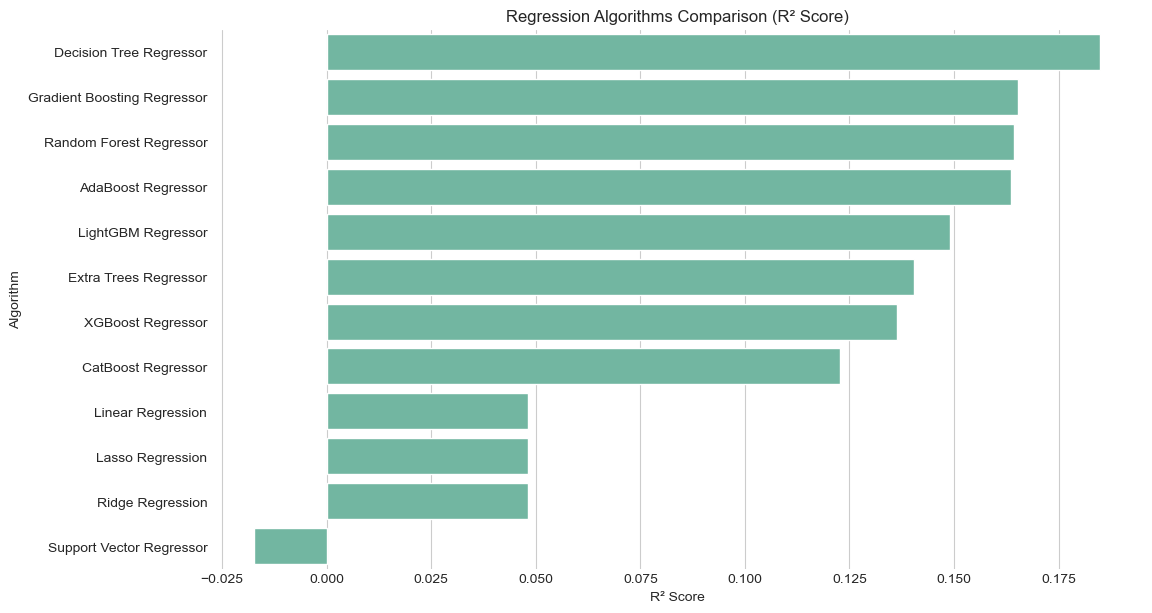


Best Performing Model:
Decision Tree Regressor
STEP 6 COMPLETED SUCCESSFULLY


In [11]:
# ==========================================================
# STEP 6: COMPLETE REGRESSION MODEL TRAINING & COMPARISON
# ==========================================================
print("=" * 80)
print("STEP 6: TRAINING MULTIPLE REGRESSION ALGORITHMS")
print("=" * 80)

# ==========================================================
# IMPORT MODELS
# ==========================================================
from sklearn.linear_model import (LinearRegression,Ridge,Lasso)
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,GradientBoostingRegressor,
    ExtraTreesRegressor,AdaBoostRegressor)
from sklearn.svm import SVR
# Bonus models
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor

# Metrics
from sklearn.metrics import (mean_absolute_error,mean_squared_error,r2_score)

# ==========================================================
# DEFINE ALL MODELS
# ==========================================================
models = {
# Required Models
"Linear Regression":LinearRegression(),
"Ridge Regression":Ridge(alpha=1.0),
"Lasso Regression":Lasso(alpha=0.001),
"Decision Tree Regressor":DecisionTreeRegressor(random_state=42),
"Random Forest Regressor":RandomForestRegressor(n_estimators=200,random_state=42),
"Gradient Boosting Regressor":GradientBoostingRegressor(random_state=42),
"Support Vector Regressor":SVR(kernel="rbf"),

# Bonus Models
"XGBoost Regressor":XGBRegressor(n_estimators=200,learning_rate=0.05,random_state=42),
"Extra Trees Regressor":ExtraTreesRegressor(n_estimators=200,random_state=42),
"AdaBoost Regressor":AdaBoostRegressor(n_estimators=100,random_state=42),
"CatBoost Regressor":CatBoostRegressor(iterations=300,learning_rate=0.05,verbose=0,random_state=42),
"LightGBM Regressor":LGBMRegressor(n_estimators=200,learning_rate=0.05,random_state=42)
}

# ==========================================================
# TRAIN AND EVALUATE MODELS
# ==========================================================
results=[]
trained_models={}
for name, model in models.items():
    print("\nTraining:", name)
    # Train
    model.fit(
        X_train_scaled,
        y_train
    )
    trained_models[name]=model
    # Prediction
    y_pred=model.predict(X_test_scaled)
    # Evaluation
    mae=mean_absolute_error(y_test,y_pred)
    rmse=np.sqrt(mean_squared_error(y_test,y_pred))
    r2=r2_score(y_test,y_pred)
    results.append({
        "Model":name,
        "MAE":mae,
        "RMSE":rmse,
        "R2 Score":r2})

# ==========================================================
# MODEL COMPARISON
# ==========================================================
results_df=pd.DataFrame(results)
results_df=results_df.sort_values(by="R2 Score",ascending=False)
print("\nFINAL MODEL PERFORMANCE COMPARISON")
display(results_df)

# ==========================================================
# VISUAL COMPARISON
# ==========================================================
plt.figure(figsize=(12,7))
sns.barplot(data=results_df,x="R2 Score",y="Model")
plt.title("Regression Algorithms Comparison (R² Score)")
plt.xlabel("R² Score")
plt.ylabel("Algorithm")
plt.show()

# ==========================================================
# BEST MODEL SELECTION
# ==========================================================
best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]
print("\nBest Performing Model:")
print(best_model_name)
print("=" * 80)
print("STEP 6 COMPLETED SUCCESSFULLY")
print("=" * 80)

In [12]:
# ==========================================================
# CHECK BEST MODEL FROM STEP 6
# ==========================================================
print("Best Model From STEP 6:")
print(best_model_name)
print("\nModel Parameters:")
print(best_model.get_params())

Best Model From STEP 6:
Decision Tree Regressor

Model Parameters:
{'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': 42, 'splitter': 'best'}


In [13]:
# ==========================================================
# STEP 7: HYPERPARAMETER OPTIMIZATION
# =========================================================
print("=" * 80)
print("STEP 7: HYPERPARAMETER TUNING")
print("=" * 80)
from sklearn.model_selection import GridSearchCV

# ==========================================================
# RANDOM FOREST TUNING
# ==========================================================
rf_model = RandomForestRegressor(random_state=42)
rf_parameters = {
    "n_estimators":[100,200,300],
    "max_depth":[None,10,20],
    "min_samples_split":[2,5],
    "min_samples_leaf":[1,2]
}
grid_rf = GridSearchCV(
    estimator=rf_model,
    param_grid=rf_parameters,
    cv=5,scoring="r2",n_jobs=-1)
print("Tuning Random Forest...")
grid_rf.fit(X_train_scaled,y_train)
print("\nBest Parameters:")
print(grid_rf.best_params_)
print("\nBest Cross Validation Score:")
print(grid_rf.best_score_)
best_rf = grid_rf.best_estimator_

STEP 7: HYPERPARAMETER TUNING
Tuning Random Forest...

Best Parameters:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}

Best Cross Validation Score:
0.7267726876270934


In [14]:
# ==========================================================
# EVALUATE OPTIMIZED MODEL
# ==========================================================
y_pred_tuned = best_rf.predict(X_test_scaled)
mae = mean_absolute_error(y_test,y_pred_tuned)
rmse = np.sqrt(mean_squared_error(y_test,y_pred_tuned))
r2 = r2_score(y_test,y_pred_tuned)
tuning_results = pd.DataFrame({
    "Metric":["MAE","RMSE","R2 Score"],
    "Value":[mae,rmse,r2]})
display(tuning_results)
print("Hyperparameter Optimization Completed.")

,Metric,Value
0,MAE,20750.008446
1,RMSE,130475.621619
2,R2 Score,0.167111


Hyperparameter Optimization Completed.


In [15]:
# ==========================================================
# BEFORE VS AFTER TUNING
# ==========================================================
original_score = results_df[
    results_df["Model"]=="Random Forest Regressor"
]["R2 Score"].values[0]
comparison = pd.DataFrame({
    "Model":[
        "Random Forest Before Tuning",
        "Random Forest After Tuning"],
    "R2 Score":[original_score,r2]})
display(comparison)

,Model,R2 Score
0,Random Forest Before Tuning,0.164316
1,Random Forest After Tuning,0.167111


STEP 8: MODEL INTERPRETATION

Feature Importance Analysis


,Feature,Importance
3,milage,0.374657
5,engine,0.334018
1,model,0.097478
0,brand,0.064456
2,model_year,0.046063
7,ext_col,0.034514
6,transmission,0.022467
8,int_col,0.020916
4,fuel_type,0.004140
9,accident,0.001292


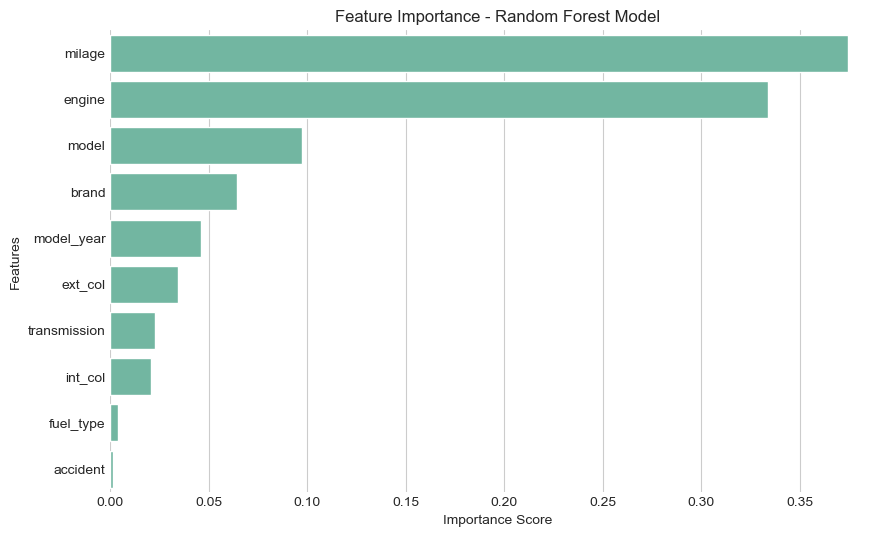

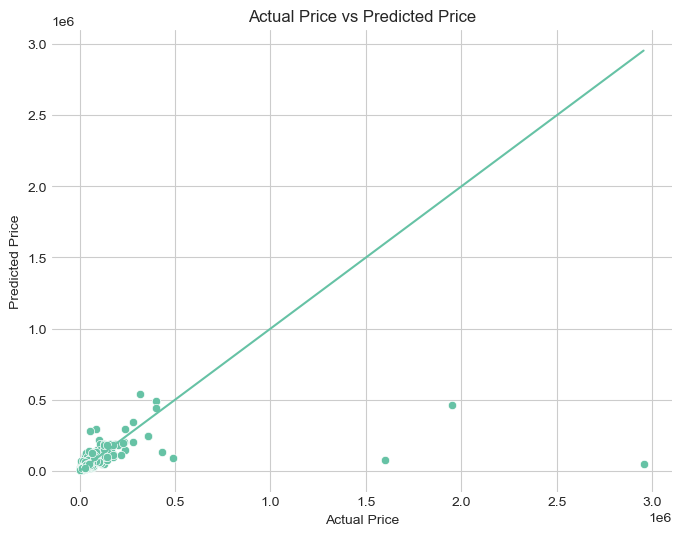

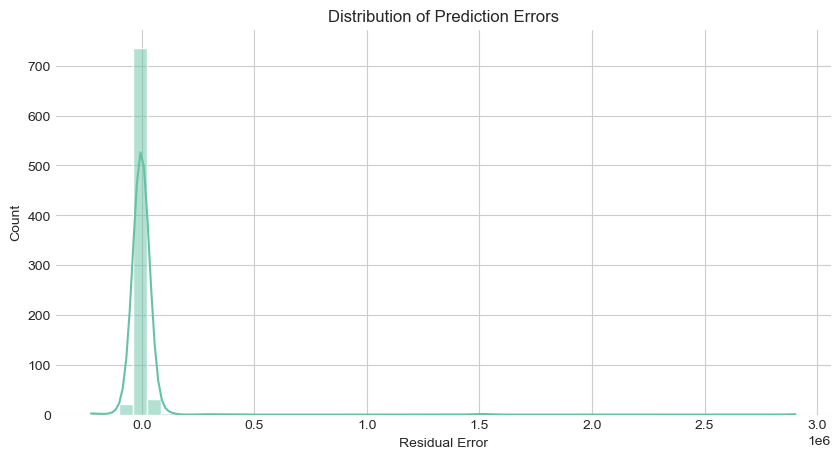

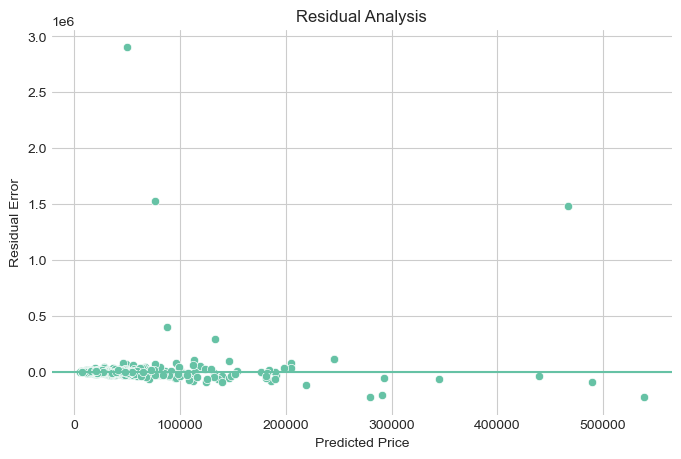

,Actual Price,Predicted Price,Difference
0,28000,41869.567012,-13869.567012
1,5900,19711.829189,-13811.829189
2,41000,47495.940615,-6495.940615
3,40250,55197.606066,-14947.606066
4,77999,50953.328977,27045.671023
5,35899,37268.904571,-1369.904571
6,36000,46458.300132,-10458.300132
7,47214,74879.216288,-27665.216288
8,30900,19206.987158,11693.012842
9,11000,10708.804226,291.195774


,Metric,Value
0,MAE,20750.008446
1,RMSE,130475.621619
2,R2 Score,0.167111


STEP 8 COMPLETED SUCCESSFULLY


In [16]:
# ==========================================================
# STEP 8: MODEL INTERPRETATION & FEATURE IMPORTANCE
# ==========================================================
print("=" * 80)
print("STEP 8: MODEL INTERPRETATION")
print("=" * 80)

# ==========================================================
# FEATURE IMPORTANCE
# ==========================================================
print("\nFeature Importance Analysis")
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_rf.feature_importances_})
importance = importance.sort_values(by="Importance",ascending=False)
display(importance)

# ==========================================================
# FEATURE IMPORTANCE VISUALIZATION
# ==========================================================
plt.figure(figsize=(10,6))
sns.barplot(data=importance,x="Importance",y="Feature")
plt.title("Feature Importance - Random Forest Model")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()


# ==========================================================
# ACTUAL VS PREDICTED VALUES
# ==========================================================
y_pred = best_rf.predict(X_test_scaled)
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test,y=y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual Price vs Predicted Price")
# Perfect prediction line
plt.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()])
plt.show()

# ==========================================================
# RESIDUAL ANALYSIS
# ==========================================================
residuals = y_test - y_pred
plt.figure(figsize=(10,5))
sns.histplot(residuals,bins=50,kde=True)
plt.title("Distribution of Prediction Errors")
plt.xlabel("Residual Error")
plt.show()

# ==========================================================
# RESIDUAL SCATTER PLOT
# ==========================================================
plt.figure(figsize=(8,5))
sns.scatterplot(x=y_pred,y=residuals)
plt.axhline(y=0)
plt.xlabel("Predicted Price")
plt.ylabel("Residual Error")
plt.title("Residual Analysis")
plt.show()

# ==========================================================
# SAMPLE PRICE PREDICTIONS
# ==========================================================
prediction_results = pd.DataFrame({"Actual Price": y_test.values,"Predicted Price": y_pred})
prediction_results["Difference"] = (
    prediction_results["Actual Price"]
    -
    prediction_results["Predicted Price"])
display(prediction_results.head(10))

# ==========================================================
# FINAL MODEL PERFORMANCE
# ==========================================================
final_mae = mean_absolute_error(y_test,y_pred)
final_rmse = np.sqrt(mean_squared_error(y_test,y_pred))
final_r2 = r2_score(y_test,y_pred)
final_results = pd.DataFrame({
    "Metric":["MAE","RMSE","R2 Score"],
    "Value":[final_mae,final_rmse,final_r2]})
display(final_results)
print("=" * 80)
print("STEP 8 COMPLETED SUCCESSFULLY")
print("=" * 80)

In [17]:
# ==========================================================
# STEP 9: SAVE FINAL MODEL FILES
# ==========================================================
import os
import joblib
import json
os.makedirs("models",exist_ok=True)
# Model
joblib.dump(best_rf,"models/car_price_model.pkl")
# Scaler
joblib.dump(scaler,"models/scaler.pkl")
# Encoders
joblib.dump(label_encoders,"models/label_encoders.pkl")
# Features
feature_info={
"features":X.columns.tolist(),
"number_of_features":X.shape[1]
}
with open("models/features.json","w"
) as f:
    json.dump(feature_info,f,indent=4)
print("All files saved successfully")
print(os.listdir("models"))

All files saved successfully
['car_price_model.pkl', 'features.json', 'label_encoders.pkl', 'scaler.pkl']
